In [1]:
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
run = ds.pipeline.open(label="docs_default")
graph = run["connectivity_map"]

Downloading bucket files: 56073178 / 56073178 complete

Downloading bytes: 56073178 / 56073178 complete

In [2]:
diffusion_operators = {
    t: ds.run_diffusion_operator(graph, t=t)
    for t in (1, 2, 4)
}
diffused_by_t = {
    t: ds.get_imputed(feature_name="CD4", diffusion=diffusion)
    for t, diffusion in diffusion_operators.items()
}
for t, values in diffused_by_t.items():
    ds.cells.insert(f"CD4_imputed_t{t}", values, key="I", overwrite=True)

In [3]:
observed = ds.get_cell_vals(from_assay="RNA", cell_key="I", k="CD4")
cd4_series = {
    "Observed CD4": observed,
    **{f"Diffusion t={t}": values for t, values in diffused_by_t.items()},
}
cd4_summary = pd.DataFrame(
    {
        label: {
            "mean": float(vals.mean()),
            "max": float(vals.max()),
            "zero_fraction": float((vals == 0).mean()),
            "filled_zeros": int(((observed == 0) & (vals > 0)).sum()),
        }
        for label, vals in cd4_series.items()
    }
).T
cd4_summary

,mean,max,zero_fraction,filled_zeros
Observed CD4,0.069966,0.816104,0.641371,0.0
Diffusion t=1,0.069559,0.352813,0.228680,1638.0
Diffusion t=2,0.069604,0.299907,0.035533,2387.0
Diffusion t=4,0.069618,0.266565,0.000000,2527.0


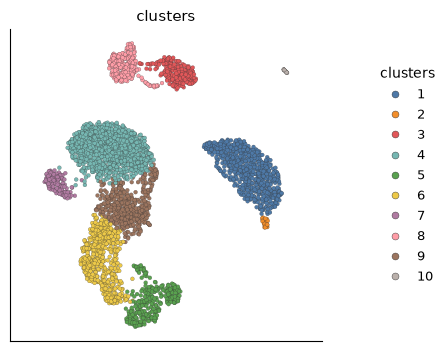

In [4]:
ds.plots.embedding(
    run=run,
    layout="umap",
    color_by="clusters",
)

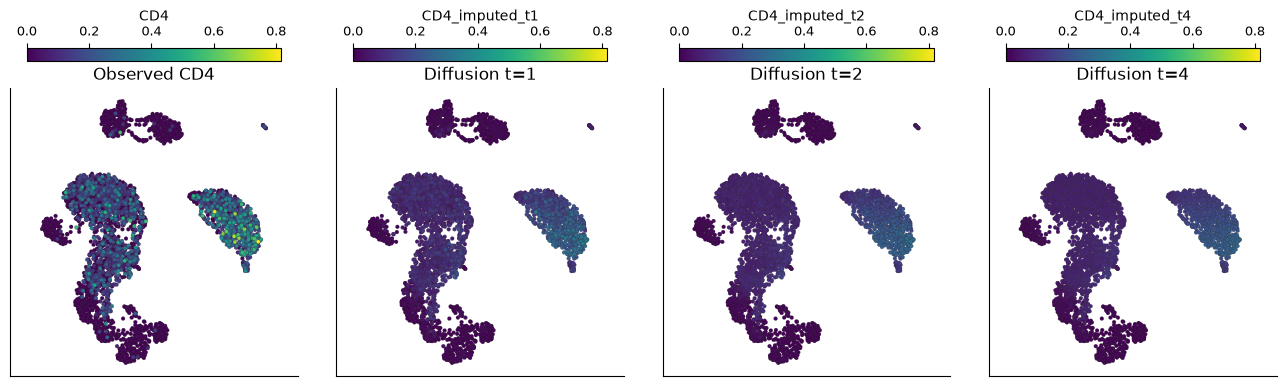

In [5]:
imputation_comparison = ds.plots.embedding(
    layout=run["umap"],
    color_by=[
        "CD4",
        "CD4_imputed_t1",
        "CD4_imputed_t2",
        "CD4_imputed_t4",
    ],
    n_columns=4,
    color_scale=splt.ColorScale(scope="shared"),
    sort_values=True,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    imputation_comparison.axes.values(),
    ("Observed CD4", "Diffusion t=1", "Diffusion t=2", "Diffusion t=4"),
    strict=True,
):
    axis.set_title(title)
imputation_comparison.figure